In [8]:
import pandas as pd
import numpy as np
import re
import os
import glob
import pickle
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

nltk.download('stopwords')
nltk.download('wordnet')


# ============================================================
# STEP 1: Load Reddit Data
# ============================================================
base_path = "/kaggle/input/datasets/entenam/reddit-mental-health-dataset/Original Reddit Data/raw data"
all_files = glob.glob(base_path + "/**/*.csv", recursive=True)

dfs = []
for f in all_files:
    try:
        temp = pd.read_csv(f, on_bad_lines='skip')
        dfs.append(temp)
    except:
        pass

df_reddit = pd.concat(dfs, ignore_index=True)
df_reddit = df_reddit[["selftext", "subreddit"]].copy()
df_reddit.columns = ["text", "label"]

label_map = {
    "SuicideWatch": "suicidal",
    "depression":   "depression",
    "Anxiety":      "anxiety",
    "mentalhealth": "normal",
    "lonely":       "loneliness",
    "loneliness":   "loneliness"
}
df_reddit["label"] = df_reddit["label"].map(label_map)
df_reddit = df_reddit.dropna(subset=["label"])
print("Reddit Data:", df_reddit.shape)
print(df_reddit["label"].value_counts())


# ============================================================
# STEP 2: Load Mental Health Classification Dataset
# ============================================================
df_mh = pd.read_csv("/kaggle/input/datasets/priyangshumukherjee/mental-health-text-classification-dataset/mental_heath_unbanlanced.csv")
df_mh = df_mh[["text", "status"]].copy()
df_mh.columns = ["text", "label"]
df_mh["label"] = df_mh["label"].str.lower().str.strip()
print("\nMH Dataset:", df_mh.shape)
print(df_mh["label"].value_counts())


# ============================================================
# STEP 3: Load Sentiment Dataset — Anxiety only
# ============================================================
df_new = pd.read_csv("/kaggle/input/datasets/suchintikasarkar/sentiment-analysis-for-mental-health/Combined Data.csv")
df_new = df_new[["statement", "status"]].copy()
df_new.columns = ["text", "label"]
df_new["label"] = df_new["label"].str.lower().str.strip()
df_extra = df_new[df_new["label"] == "anxiety"].copy()
print("\nSentiment Dataset — Anxiety rows:", df_extra.shape)


# ============================================================
# STEP 4: Merge All Three Datasets
# ============================================================

df_combined = pd.concat([df_reddit, df_mh, df_extra], ignore_index=True)
df_combined = df_combined.dropna(subset=["text"])
df_combined = df_combined[df_combined["text"].str.strip() != ""]
df_combined = df_combined[df_combined["text"] != "[deleted]"]
df_combined = df_combined[df_combined["text"] != "[removed]"]

df_combined["text_length"] = df_combined["text"].str.len()
df_combined["word_count"]  = df_combined["text"].str.split().str.len()
df_combined["clean_text"]  = ""
df_combined["source"]      = (
    ["reddit"]     * len(df_reddit) +
    ["mh_dataset"] * len(df_mh)     +
    ["sentiment"]  * len(df_extra)
)[:len(df_combined)]

df_combined = df_combined.sample(frac=1, random_state=42).reset_index(drop=True)

print("After Merge:", df_combined.shape)
print(df_combined["label"].value_counts())
print(df_combined.head(10))

2026-05-17 15:34:53.694456: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779032094.143163      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779032094.274224      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779032095.370100      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779032095.370144      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779032095.370147      57 computation_placer.cc:177] computation placer alr

Reddit Data: (1847870, 2)
label
depression    624561
suicidal      483048
normal        303109
anxiety       280038
loneliness    157114
Name: count, dtype: int64

MH Dataset: (49612, 2)
label
normal        18391
depression    14506
suicidal      11212
anxiety        5503
Name: count, dtype: int64

Sentiment Dataset — Anxiety rows: (3888, 2)
After Merge: (1663662, 6)
label
depression    541480
suicidal      415927
normal        297571
anxiety       267542
loneliness    141142
Name: count, dtype: int64
                                                text       label  text_length  \
0  I know what led up to having a depressive epis...  depression          188   
1  TW for sexual assault\n\nI was never assaulted...      normal         1348   
2  Well, I just got my test results back today fr...    suicidal          997   
3  I had two weeks to write my essay, but didn't ...    suicidal          616   
4  So basically I () have only 1 real friend and ...  loneliness          505   
5  Hell

In [9]:
# ============================================================
# STEP 5: Random Oversampling
# ============================================================
target_size = df_combined["label"].value_counts().max()

dfs_balanced = []
for label in df_combined["label"].unique():
    df_class = df_combined[df_combined["label"] == label]
    if len(df_class) < target_size:
        df_class = resample(df_class,
                            replace=True,
                            n_samples=target_size,
                            random_state=42)
    dfs_balanced.append(df_class)

df_balanced = pd.concat(dfs_balanced, ignore_index=True)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)
print("\nAfter Oversampling:", df_balanced.shape)
print(df_balanced["label"].value_counts())


# ============================================================
# STEP 6: Sample 500K
# ============================================================
df_balanced = df_balanced.sample(n=500000, random_state=42)
print("\nAfter Sampling:", df_balanced.shape)


# ============================================================
# STEP 7: Text Preprocessing
# ============================================================
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return " ".join(tokens)

df_balanced["clean_text"] = df_balanced["text"].apply(preprocess)
df_balanced["clean_text"] = df_balanced["clean_text"].fillna("") 
df_balanced = df_balanced[df_balanced["clean_text"].str.split().str.len() >= 5]
df_balanced = df_balanced.dropna(subset=["clean_text"])
print("\nAfter Text Preprocessing:", df_balanced.shape)
print(df_balanced["label"].value_counts())
# ============================================================
# STEP 8: Label Encoding
# ============================================================
le = LabelEncoder()
df_balanced["label_encoded"] = le.fit_transform(df_balanced["label"])
print("\nClasses:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} -> {cls}")


# ============================================================
# STEP 9: Tokenization and Padding
# ============================================================
MAX_WORDS = 50000
MAX_LEN   = 200

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(df_balanced["clean_text"])

X = tokenizer.texts_to_sequences(df_balanced["clean_text"])
X = pad_sequences(X, maxlen=MAX_LEN, padding="post", truncating="post")
y = df_balanced["label_encoded"].values
print("\nX shape:", X.shape)
print("y shape:", y.shape)


# ============================================================
# STEP 10: Train / Validation / Test Split
# ============================================================
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("\nTrain:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)


# ============================================================
# STEP 11: Save All Data for Team
# ============================================================
data_to_save = {
    'X_train':       X_train,
    'y_train':       y_train,
    'X_val':         X_val,
    'y_val':         y_val,
    'X_test':        X_test,
    'y_test':        y_test,
    'tokenizer':     tokenizer,
    'label_encoder': le,
    'MAX_WORDS':     MAX_WORDS,
    'MAX_LEN':       MAX_LEN,
    'NUM_CLASSES':   len(le.classes_),
    'classes':       le.classes_.tolist()
}

with open('team_data.pkl', 'wb') as f:
    pickle.dump(data_to_save, f)

print("\nSaved: team_data.pkl")
print("Classes:    ", le.classes_.tolist())
print("NUM_CLASSES:", len(le.classes_))
print("MAX_WORDS:  ", MAX_WORDS)
print("MAX_LEN:    ", MAX_LEN)


After Oversampling: (2707400, 6)
label
depression    541480
normal        541480
loneliness    541480
suicidal      541480
anxiety       541480
Name: count, dtype: int64

After Sampling: (500000, 6)

After Text Preprocessing: (477856, 6)
label
anxiety       98275
depression    97663
normal        95044
suicidal      95001
loneliness    91873
Name: count, dtype: int64

Classes:
  0 -> anxiety
  1 -> depression
  2 -> loneliness
  3 -> normal
  4 -> suicidal

X shape: (477856, 200)
y shape: (477856,)

Train: (382284, 200)
Val:   (47786, 200)
Test:  (47786, 200)

Saved: team_data.pkl
Classes:     ['anxiety', 'depression', 'loneliness', 'normal', 'suicidal']
NUM_CLASSES: 5
MAX_WORDS:   50000
MAX_LEN:     200


In [10]:
df_combined.head()

,text,label,text_length,word_count,clean_text,source
0,I know what led up to having a depressive epis...,depression,188,38,,reddit
1,TW for sexual assault\n\nI was never assaulted...,normal,1348,255,,reddit
2,"Well, I just got my test results back today fr...",suicidal,997,195,,reddit
3,"I had two weeks to write my essay, but didn't ...",suicidal,616,115,,reddit
4,So basically I () have only 1 real friend and ...,loneliness,505,106,,reddit


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ============================================
# Attention Layer
# ============================================
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super(Attention, self).__init__()
        self.W = nn.Linear(hidden_size, hidden_size)
        self.v = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, lstm_output):
        energy = torch.tanh(self.W(lstm_output))    
        attention_weights = self.v(energy)            
        attention_weights = F.softmax(attention_weights, dim=1)  
        context = torch.sum(attention_weights * lstm_output, dim=1)  
        return context, attention_weights

# ============================================
# LSTM + Attention Model
# ============================================
class LSTMAttention(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_classes, dropout=0.3):
        super(LSTMAttention, self).__init__()
        self.embedding  = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.dropout1   = nn.Dropout(dropout)
        self.lstm       = nn.LSTM(embed_dim, hidden_size,
                                   batch_first=True,
                                   dropout=dropout)
        self.attention  = Attention(hidden_size)
        self.fc1        = nn.Linear(hidden_size, 64)
        self.dropout2   = nn.Dropout(dropout)
        self.fc2        = nn.Linear(64, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)           
        embedded = self.dropout1(embedded)

        lstm_out, _ = self.lstm(embedded)     

        context, attn_weights = self.attention(lstm_out)  
        out = F.relu(self.fc1(context))
        out = self.dropout2(out)
        out = self.fc2(out)                    
        return out

In [12]:
# ============================================
# data  PyTorch
# ============================================
from torch.utils.data import TensorDataset, DataLoader
import numpy as np

X_train_t = torch.tensor(X_train, dtype=torch.long)
y_train_t  = torch.tensor(y_train, dtype=torch.long)
X_val_t    = torch.tensor(X_val,   dtype=torch.long)
y_val_t    = torch.tensor(y_val,   dtype=torch.long)
X_test_t   = torch.tensor(X_test,  dtype=torch.long)
y_test_t   = torch.tensor(y_test,  dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=256, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),   batch_size=256)

In [13]:
# ============================================
# تdefine model and  Training
# ============================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

VOCAB_SIZE   = MAX_WORDS
EMBED_DIM    = 128
HIDDEN_SIZE  = 128
NUM_CLASSES  = 5

model = LSTMAttention(VOCAB_SIZE, EMBED_DIM, HIDDEN_SIZE, NUM_CLASSES).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

print(model)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


LSTMAttention(
  (embedding): Embedding(50000, 128, padding_idx=0)
  (dropout1): Dropout(p=0.3, inplace=False)
  (lstm): LSTM(128, 128, batch_first=True, dropout=0.3)
  (attention): Attention(
    (W): Linear(in_features=128, out_features=128, bias=True)
    (v): Linear(in_features=128, out_features=1, bias=False)
  )
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=5, bias=True)
)


In [14]:
# ============================================
# Training Loop
# ============================================
EPOCHS = 10
best_val_loss = float('inf')

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    train_loss, train_correct = 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
        optimizer.step()
        train_loss    += loss.item()
        train_correct += (outputs.argmax(1) == y_batch).sum().item()

    # --- Validation ---
    model.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs   = model(X_batch)
            val_loss += criterion(outputs, y_batch).item()
            val_correct += (outputs.argmax(1) == y_batch).sum().item()

    train_acc = train_correct / len(X_train_t)
    val_acc   = val_correct   / len(X_val_t)
    avg_val_loss = val_loss / len(val_loader)

    scheduler.step(avg_val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss/len(train_loader):.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "lstm_attention_best.pt")
        print("  ✓ saved best model")

Epoch 1/10 | Train Loss: 1.1012 | Train Acc: 0.5613 | Val Loss: 0.9999 | Val Acc: 0.6081
  ✓ saved best model
Epoch 2/10 | Train Loss: 0.9852 | Train Acc: 0.6176 | Val Loss: 0.9542 | Val Acc: 0.6290
  ✓ saved best model
Epoch 3/10 | Train Loss: 0.9507 | Train Acc: 0.6323 | Val Loss: 0.9353 | Val Acc: 0.6347
  ✓ saved best model
Epoch 4/10 | Train Loss: 0.9289 | Train Acc: 0.6416 | Val Loss: 0.9298 | Val Acc: 0.6394
  ✓ saved best model
Epoch 5/10 | Train Loss: 0.9093 | Train Acc: 0.6488 | Val Loss: 0.9210 | Val Acc: 0.6442
  ✓ saved best model
Epoch 6/10 | Train Loss: 0.8941 | Train Acc: 0.6560 | Val Loss: 0.9121 | Val Acc: 0.6462
  ✓ saved best model
Epoch 7/10 | Train Loss: 0.8796 | Train Acc: 0.6620 | Val Loss: 0.9104 | Val Acc: 0.6476
  ✓ saved best model
Epoch 8/10 | Train Loss: 0.8682 | Train Acc: 0.6665 | Val Loss: 0.9057 | Val Acc: 0.6486
  ✓ saved best model
Epoch 9/10 | Train Loss: 0.8551 | Train Acc: 0.6714 | Val Loss: 0.9139 | Val Acc: 0.6490
Epoch 10/10 | Train Loss: 0.843

In [15]:

from sklearn.metrics import classification_report

model.load_state_dict(torch.load("lstm_attention_best.pt"))
model.eval()

all_preds = []
with torch.no_grad():
    for X_batch, _ in DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=256):
        preds = model(X_batch.to(device)).argmax(1).cpu().numpy()
        all_preds.extend(preds)

print(classification_report(y_test, all_preds, target_names=le.classes_))

model.eval()
lstm_probs = []
with torch.no_grad():
    for X_batch, _ in DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=256):
        probs = torch.softmax(model(X_batch.to(device)), dim=1).cpu().numpy()
        lstm_probs.extend(probs)
lstm_probs = np.array(lstm_probs)

              precision    recall  f1-score   support

     anxiety       0.77      0.81      0.79      9828
  depression       0.53      0.39      0.45      9766
  loneliness       0.70      0.81      0.75      9188
      normal       0.61      0.50      0.55      9504
    suicidal       0.59      0.74      0.66      9500

    accuracy                           0.65     47786
   macro avg       0.64      0.65      0.64     47786
weighted avg       0.64      0.65      0.64     47786



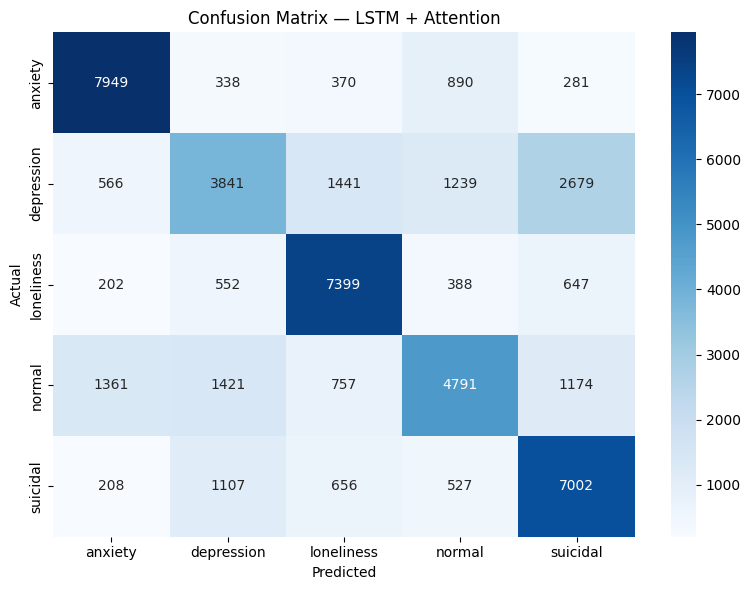

              precision    recall  f1-score   support

     anxiety       0.77      0.81      0.79      9828
  depression       0.53      0.39      0.45      9766
  loneliness       0.70      0.81      0.75      9188
      normal       0.61      0.50      0.55      9504
    suicidal       0.59      0.74      0.66      9500

    accuracy                           0.65     47786
   macro avg       0.64      0.65      0.64     47786
weighted avg       0.64      0.65      0.64     47786



In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Confusion Matrix
cm = confusion_matrix(y_test, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — LSTM + Attention')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

# Classification Report
print(classification_report(y_test, all_preds, target_names=le.classes_))

In [17]:
import numpy as np
np.save('lstm_attention_probs.npy', lstm_probs)
print("saved!")

saved!


In [18]:
import pickle

team_data = {
    'tokenizer': tokenizer,
    'label_encoder': le,
    'MAX_WORDS': MAX_WORDS,
    'MAX_LEN': MAX_LEN,
    'NUM_CLASSES': 5,
    'classes': le.classes_,
    'X_test': X_test,
    'y_test': y_test
}

with open('team_data.pkl', 'wb') as f:
    pickle.dump(team_data, f)

print("✓ Saved!")

✓ Saved!


In [20]:
df_balanced[["text", "clean_text", "label"]].to_csv('merged_data.csv', index=False)
print("✓ Saved merged_data.csv")

✓ Saved merged_data.csv
